In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope

In [2]:
DataFrame = pd.read_csv("vehicle_drinving_measurement.csv")
print(DataFrame)

       VehV  SteeringAg   LatA  YawRate   LgtA  WhlFx_FL  WhlFx_RL  WhlFx_FR  \
0     58.94    0.138866  0.001  0.16588  0.017       117       117       181   
1     58.99    0.138866  0.001  0.31746  0.016       117       100       164   
2     58.85    0.138866  0.000  0.41756  0.015       134       117       181   
3     58.90    0.138866 -0.003  0.51480  0.014       174       149       198   
4     58.95    0.148022 -0.010  0.61204  0.015       194       130       213   
...     ...         ...    ...      ...    ...       ...       ...       ...   
3297  42.71    0.210588  0.002  0.26312  0.037       222       222       345   
3298  42.77    0.219744 -0.019  0.46618  0.037       242       242       348   
3299  42.83    0.225848 -0.024  0.61204  0.037       262       262       348   
3300  42.89    0.225848 -0.013  0.61204  0.036       290       290       326   
3301  42.92    0.225848 -0.007  0.56342  0.035       262       262       303   

      WhlFx_RR  
0          164  
1    

In [3]:
# Function to create moving windows
def CreateMovingWindow(df, ws): 
    #df Dataframe; ws WidownSize
	windows = []
	for i in range(df.shape[0] - ws + 1):
		wd = df.iloc[i:i + ws,:]
		windows.append(wd)
	return np.array(windows)

In [4]:
WindowSize = 100
NewData = CreateMovingWindow(DataFrame, WindowSize)
print(NewData.shape)

(3203, 100, 9)


In [5]:
NewData = NewData.reshape(NewData.shape[0], -1)
print(NewData.shape)

(3203, 900)


In [6]:
NoOfCluster = range(1,20)
KM = [KMeans(n_clusters = i, random_state=1).fit(NewData) for i in NoOfCluster]

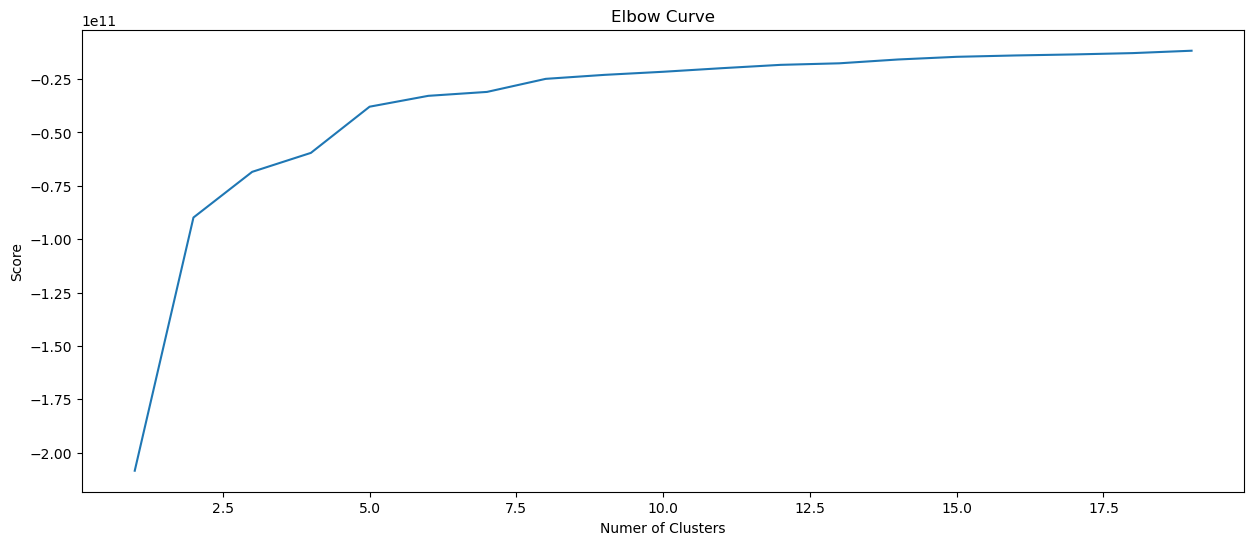

In [7]:
Scores = [KM[i].score(NewData) for i in range(len(KM))]

# Plot the score value in relation to the number of clusters
figure2 = plt.figure(figsize=(15,6))
plt.plot(NoOfCluster, Scores)
plt.xlabel('Numer of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.show()

In [8]:
PredictDrivSituation= KM[9].predict(NewData)

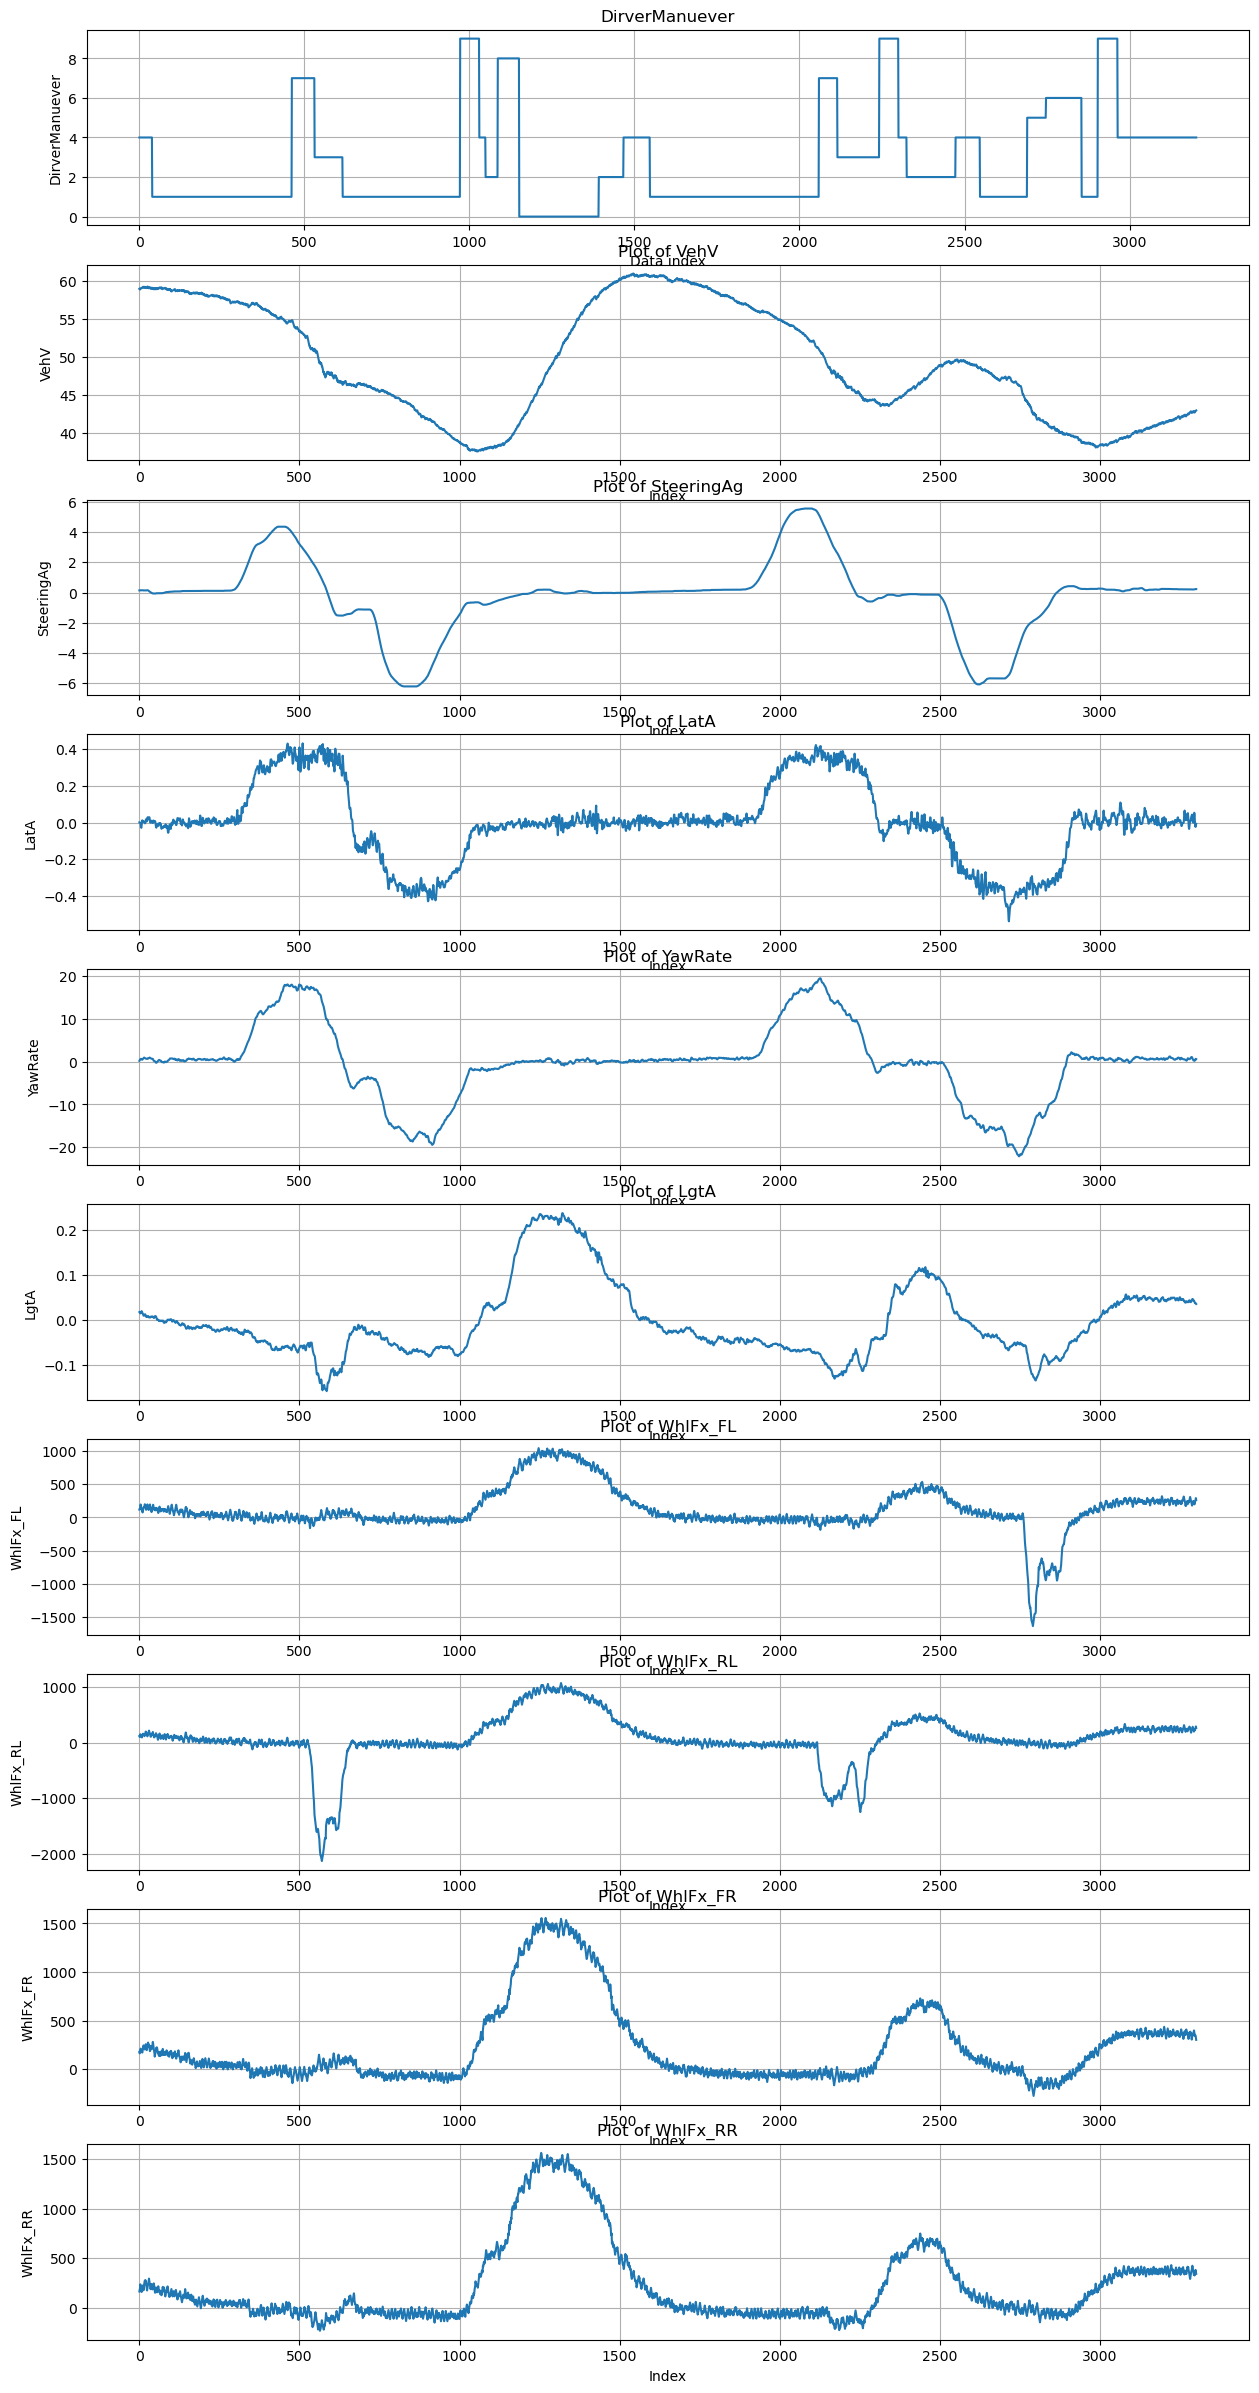

In [9]:
figure3 = plt.figure(figsize=(15,30))
plt.subplot(10,1,1)
plt.plot(PredictDrivSituation)
plt.xlabel('Data index')
plt.ylabel('DirverManuever')
plt.title('DirverManuever')
plt.grid(True)
# Plot each feature
i=2;
for column in DataFrame.columns:
	 plt.subplot(10,1,i)
	 plt.plot(DataFrame[column])
	 plt.title(f'Plot of {column}')
	 plt.xlabel('Index')
	 plt.ylabel(column)
	 plt.grid(True)
	 i += 1
plt.savefig('sample.png')

In [10]:
# Autoencoders for Feature Extraction 
# https://machinelearningmastery.com/autoencoder-for-classification/
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential, Model
from keras.layers import Input, Dense
from keras.utils import plot_model
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping

In [11]:
# Function to create moving windows
# the previous one uses dataframe as input data, this one is np array
def MovingWindow(nparray, ws): 
    #df Dataframe; ws WidownSize
	windows = []
	for i in range(nparray.shape[0] - ws + 1):
		wd = nparray[i:i + ws,:]
		windows.append(wd)
	return np.array(windows)

In [12]:
# standarizing the data
# make sense?
StdData = StandardScaler().fit_transform(DataFrame)
NewStdData = MovingWindow(StdData, WindowSize)
print(NewStdData.shape)
NewStdData = NewStdData.reshape(NewStdData.shape[0], -1)
print(NewStdData.shape)

(3203, 100, 9)
(3203, 900)


In [13]:
# Define input layer
InputLayer = Input(shape=(900,))
# Define encoder layer
EncoderLayer = Dense(units=10,activation='relu')(InputLayer)
# make sense to add another normalization layer?  
# Decoder
DecoderLayer = Dense(units=900,activation='softmax')(EncoderLayer)
# Define MLP model
AutoEncoder4Cluster = Model(inputs=InputLayer, outputs= DecoderLayer)
AutoEncoder4Cluster.compile(optimizer='adam',loss='mse')
AutoEncoder4Cluster.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 900)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         9,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 900)            │         9,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,910 (73.87 KB)

 Trainable params: 18,910 (73.87 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train the model
AutoEncoder4Cluster.fit(NewStdData,NewStdData,batch_size=12, initial_epoch = 0, epochs=100, verbose=0)

In [15]:
# Create new model without the decoder layer
EncoderMdl = Model(inputs=InputLayer, outputs= EncoderLayer)
EncoderMdl.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 900)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         9,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,010 (35.20 KB)

 Trainable params: 9,010 (35.20 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Calculate the output of the encoder layer
PredCluster = EncoderMdl.predict(NewStdData)

101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 335us/step


In [17]:
# clustering encoder output 
KMOnEncoder = KMeans(n_clusters = 10, random_state=1).fit(PredCluster)

In [18]:
PredEncoderCluster = KMOnEncoder.predict(PredCluster)

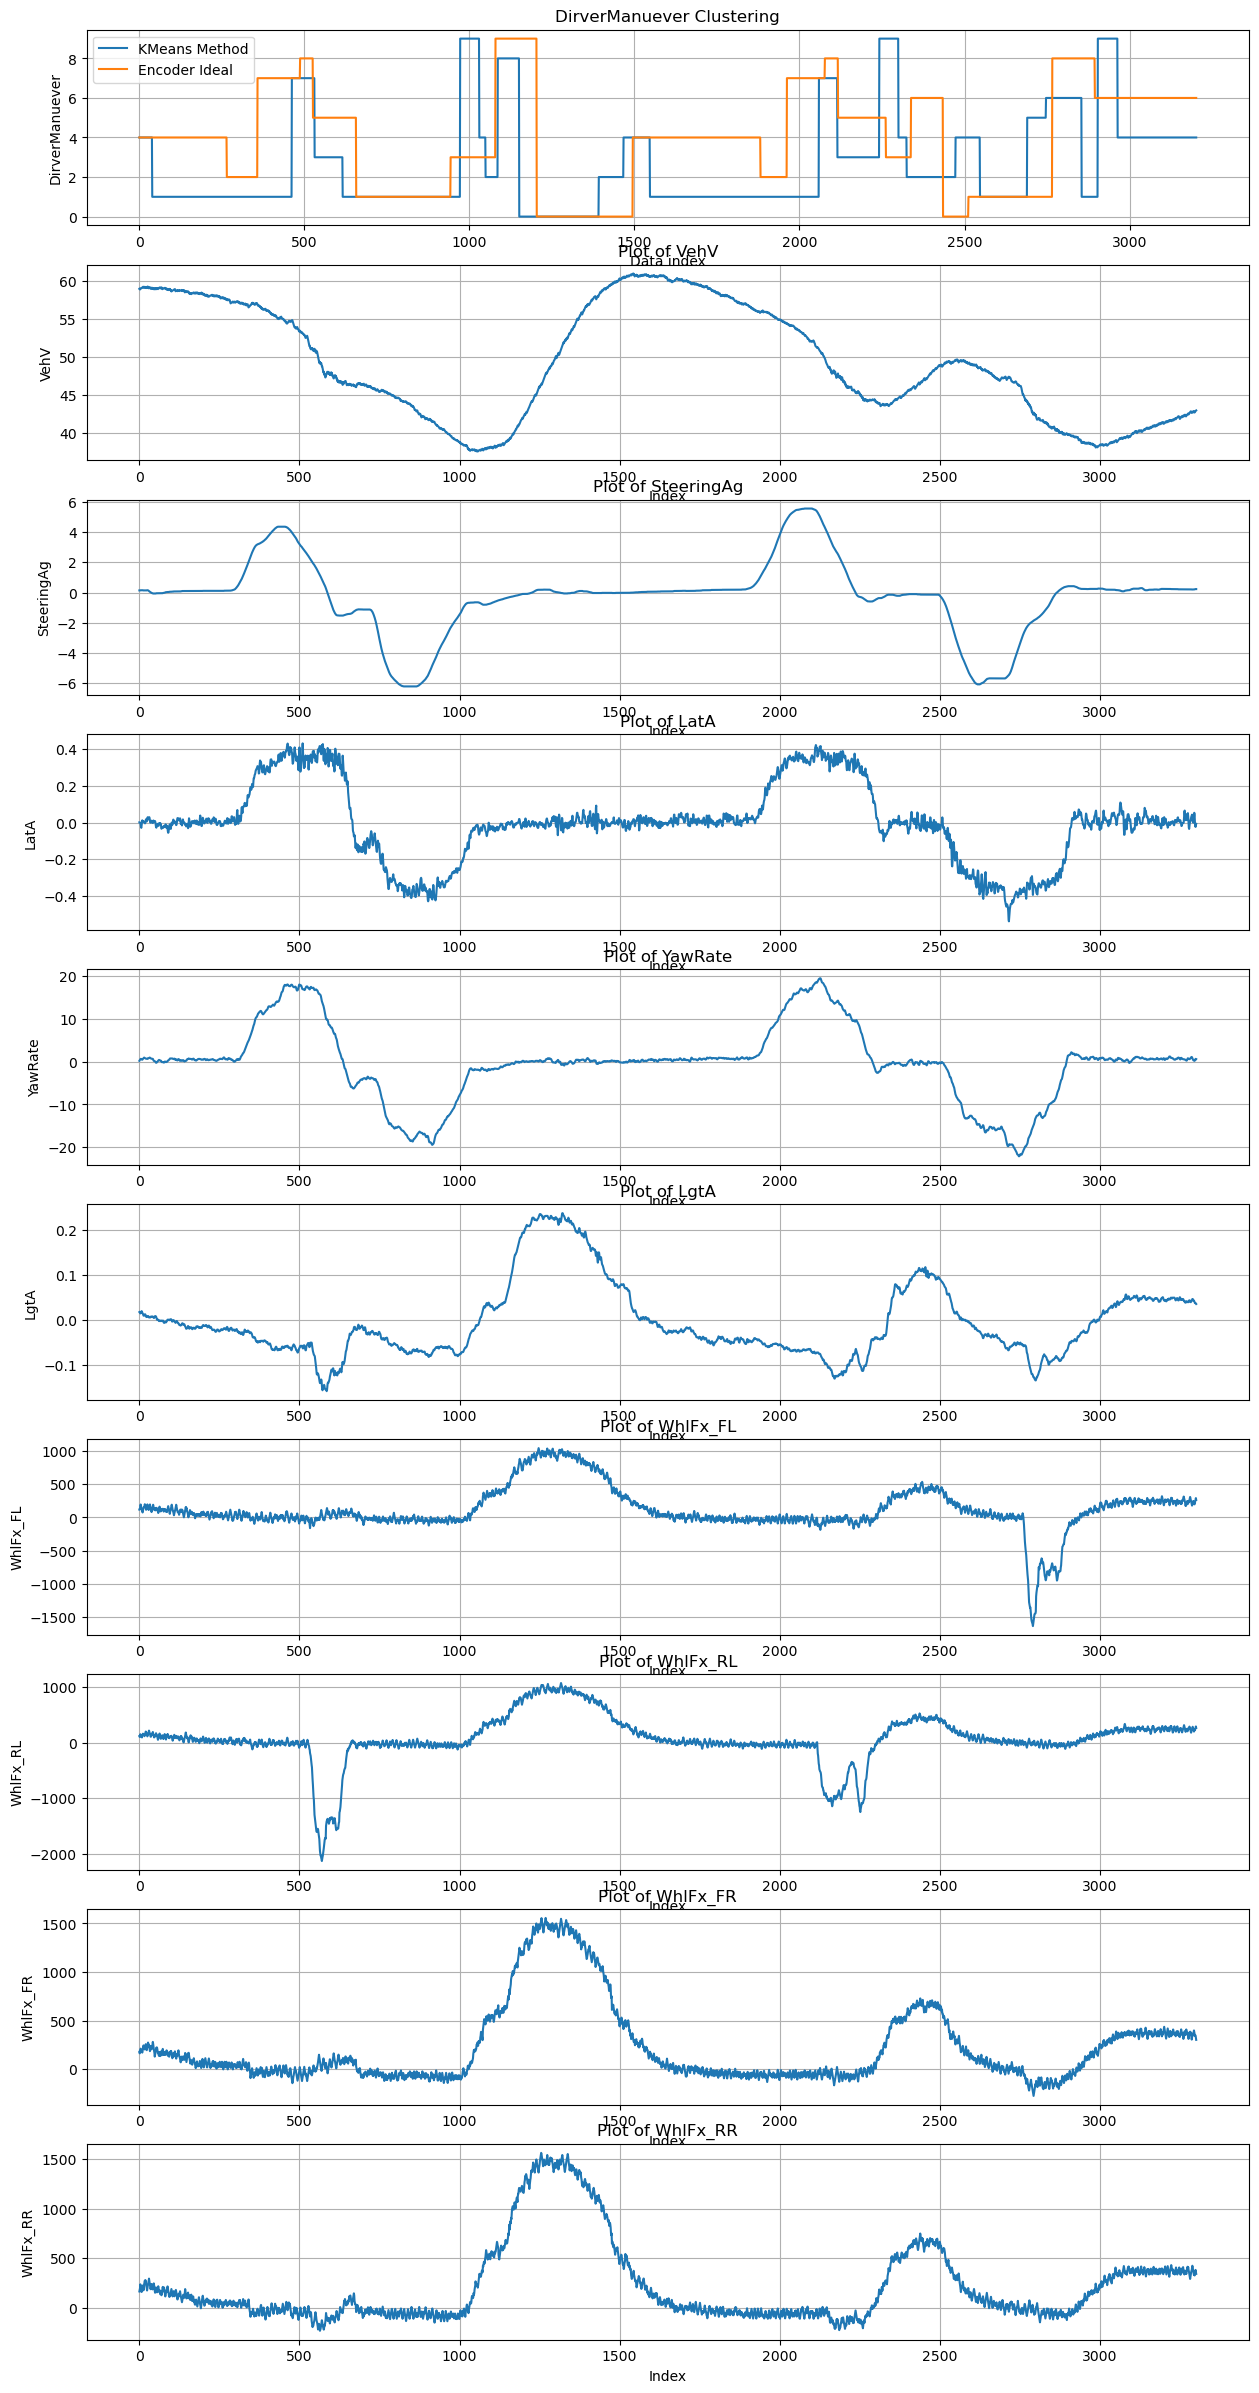

In [19]:
figure4 = plt.figure(figsize=(15,30))
plt.subplot(10,1,1)
plt.plot(PredictDrivSituation,label='KMeans Method')
plt.plot(PredEncoderCluster, label ='Encoder Ideal')
plt.xlabel('Data index')
plt.ylabel('DirverManuever')
plt.title('DirverManuever Clustering')
plt.legend()
plt.grid(True)
i=2;
for column in DataFrame.columns:
	 plt.subplot(10,1,i)
	 plt.plot(DataFrame[column])
	 plt.title(f'Plot of {column}')
	 plt.xlabel('Index')
	 plt.ylabel(column)
	 plt.grid(True)
	 i += 1
plt.savefig('sample.png')